# Project Plots

Regenerates and displays the thesis agent-evaluation plots inline without saving PNG/PDF files.

## Setup

Uses the archived paper data in `data/paperdata` with the last 10 runs per backend group.

In [15]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib-cache")
os.environ.setdefault("XDG_CACHE_HOME", "/private/tmp")

from ewfs.analysis import agent_evaluation as ae

DATA_SOURCE = "paperdata"
LAST_N = 10
OUTPUT_DIR = PROJECT_ROOT / "results" / "plots" / "not_saved_from_notebook"

PROJECT_ROOT

PosixPath('/Users/joshua/PycharmProjects/agent-like-observers-ewfs')

## Display Hook

Replaces the script's `save_plot` function with an inline display function.

In [16]:
displayed_plot_paths = []

PLOT_TITLES = {
    "hardware_agent_lf_violation_summary.png": "Hardware LF violation summary",
    "hardware_agent_lf_violation_summary_epsilon.png": "Hardware LF violation summary with epsilon bounds",
    "combined_memory_initialization_epsilon_comparison.png": "Tracking epsilon estimate",
    "reflex_agent_accuracy_comparison.png": "Reflex Agent accuracy",
    "reflex_agent_sa_m_agreement_accuracy.png": "Reflex Agent S_A/M agreement",
    "guessing_agent_accuracy_comparison.png": "Guessing Agent accuracy",
    "always_3_4_agent_accuracy_comparison.png": "Always 3/4 Agent accuracy",
    "betting_agent_accuracy_comparison.png": "Betting Agent accuracy",
    "betting_agent_vs_always_3_4_payoff_comparison.png": "Betting Agent vs Always 3/4 payoff",
}

AGENT_NAMES_BY_SLUG = {
    "reflex_agent": "Reflex Agent",
    "guessing_agent": "Guessing Agent",
    "always_3_4_agent": "Always 3/4 Agent",
    "betting_agent": "Betting Agent",
}

def lf_title_for_filename(filename: str):
    for slug, agent_name in AGENT_NAMES_BY_SLUG.items():
        if filename == f"noiseless_{slug}_lf_correlator_comparison.png":
            return f"Noiseless LF correlators: {agent_name}"
        if filename == f"hardware_comparison_{slug}_lf_correlator_comparison.png":
            return f"Noise simulation and hardware LF correlators: {agent_name}"
    return None

def title_for_plot(plot_path: Path):
    filename = plot_path.name
    return PLOT_TITLES.get(filename) or lf_title_for_filename(filename) or filename.removesuffix(".png").replace("_", " ").title()

def display_plot(fig, plot_path, *, dpi=300, bbox_inches="tight"):
    plot_path = Path(plot_path)
    displayed_plot_paths.append(plot_path)
    display(Markdown(f"### {title_for_plot(plot_path)}\n\n`{plot_path.relative_to(OUTPUT_DIR)}`"))
    display(fig)
    return plot_path

ae.save_plot = display_plot

## Load Thesis Data

In [17]:
data_dirs = ae.evaluation_data_dirs(DATA_SOURCE)
last_n_by_label = {label: LAST_N for label in ae.BACKEND_LABELS}

results = [
    ae.load_backend_result(
        "Noiseless",
        data_dirs["Noiseless"],
        "noiseless_simulation.json",
        last_n=last_n_by_label["Noiseless"],
        data_source=DATA_SOURCE,
    ),
    ae.load_backend_result(
        "Fake hardware",
        data_dirs["Fake hardware"],
        "fake_hardware_noise_sim.json",
        last_n=last_n_by_label["Fake hardware"],
        data_source=DATA_SOURCE,
    ),
    ae.load_backend_result(
        "Real hardware",
        data_dirs["Real hardware"],
        "real_hardware_run.json",
        last_n=last_n_by_label["Real hardware"],
        data_source=DATA_SOURCE,
    ),
]

accuracy_specs = [
    ("Noiseless", data_dirs["Noiseless"], "noiseless_simulation.json", ae.ACCURACY_TEST_RESULT_FILENAMES["Noiseless"]),
    ("Fake hardware", data_dirs["Fake hardware"], "fake_hardware_noise_sim.json", ae.ACCURACY_TEST_RESULT_FILENAMES["Fake hardware"]),
    ("Real hardware", data_dirs["Real hardware"], "real_hardware_run.json", ae.ACCURACY_TEST_RESULT_FILENAMES["Real hardware"]),
]

memory_inaccuracy_results = []
for label, data_dir, main_result_filename, accuracy_result_filename in accuracy_specs:
    main_result = ae.result_for_label(results, label)
    try:
        memory_inaccuracy_results.append(
            ae.load_accuracy_test_backend_result(
                label,
                data_dir,
                main_result_filename,
                accuracy_result_filename,
                last_n=last_n_by_label[label],
                data_source=DATA_SOURCE,
            )
        )
    except FileNotFoundError as exc:
        memory_inaccuracy_results.append(ae.missing_accuracy_test_result(label, main_result, exc))

memory_inaccuracy_summary = ae.build_memory_inaccuracy_summary(memory_inaccuracy_results)
tracking_epsilon_max_summary = ae.build_tracking_epsilon_max_summary(results)

selection_rows = []
for result in results:
    selection_rows.append({
        "backend_group": ae.result_display_label(result),
        "selection_mode": result["selection_mode"],
        "run_count": result["run_count"],
        "shots_total": result["raw_shots_total"],
        "backend_name": result["backend_name"],
    })

pd.DataFrame(selection_rows)

,backend_group,selection_mode,run_count,shots_total,backend_name
0,Ideal simulation,paperdata:last_10,10,1000000,NaN
1,IBM Marrakesh noise simulation,paperdata:last_10,10,100000,ibm_marrakesh
2,IBM Marrakesh hardware,paperdata:last_10,10,100000,ibm_marrakesh


## Local Friendliness Plots

### Hardware LF violation summary

`correlators_and_lf_values/comparison/hardware_agent_lf_violation_summary.png`

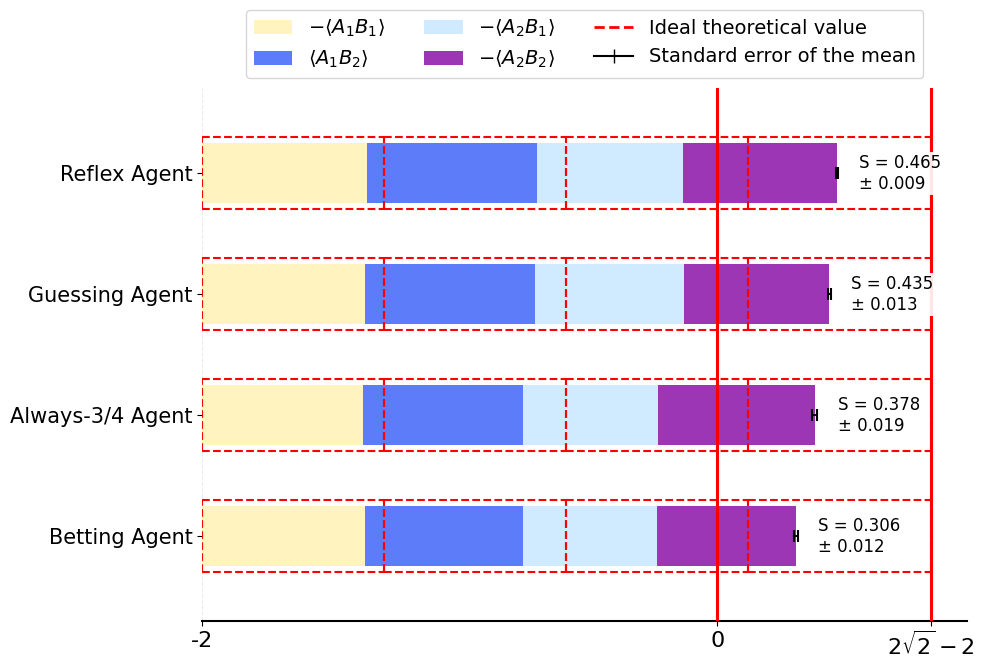

### Noiseless LF correlators: Betting Agent

`correlators_and_lf_values/noiseless/noiseless_betting_agent_lf_correlator_comparison.png`

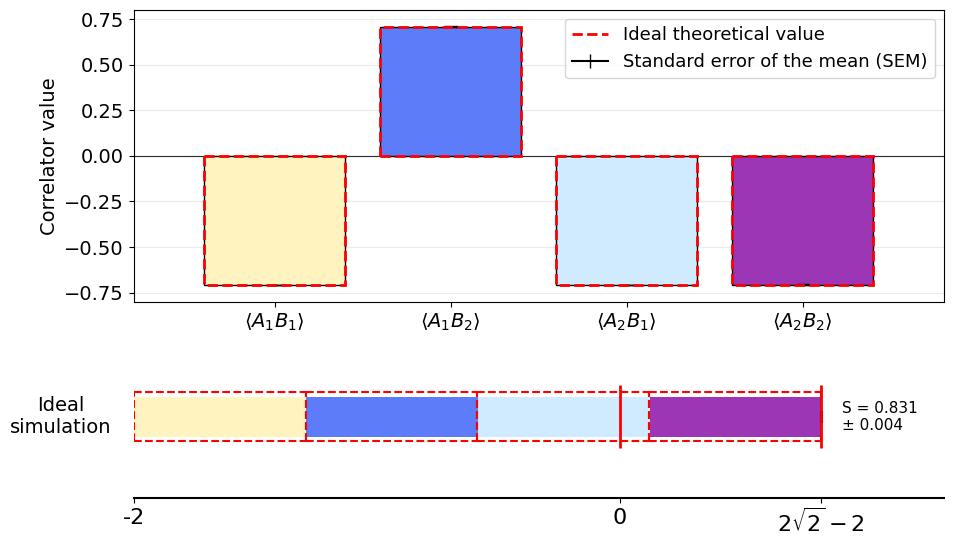

### Noiseless LF correlators: Guessing Agent

`correlators_and_lf_values/noiseless/noiseless_guessing_agent_lf_correlator_comparison.png`

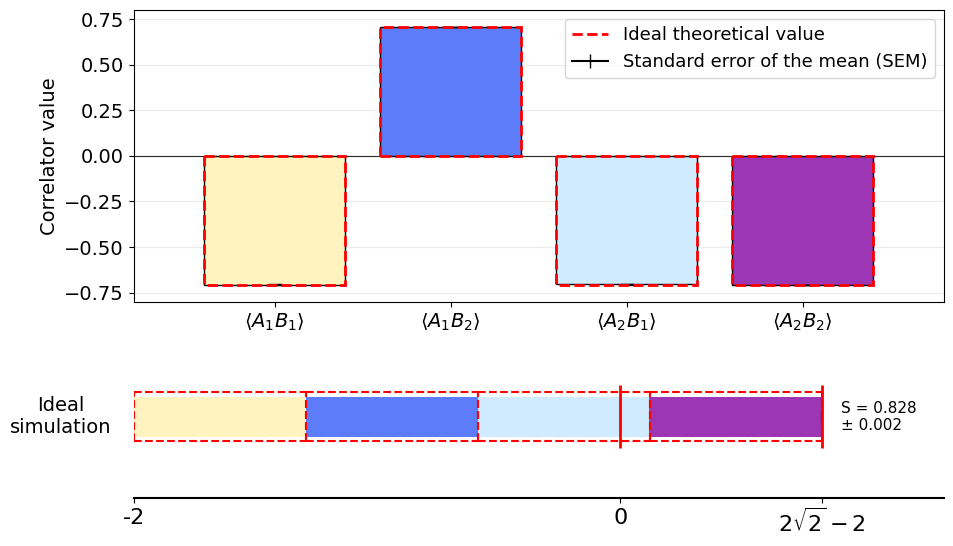

### Noiseless LF correlators: Reflex Agent

`correlators_and_lf_values/noiseless/noiseless_reflex_agent_lf_correlator_comparison.png`

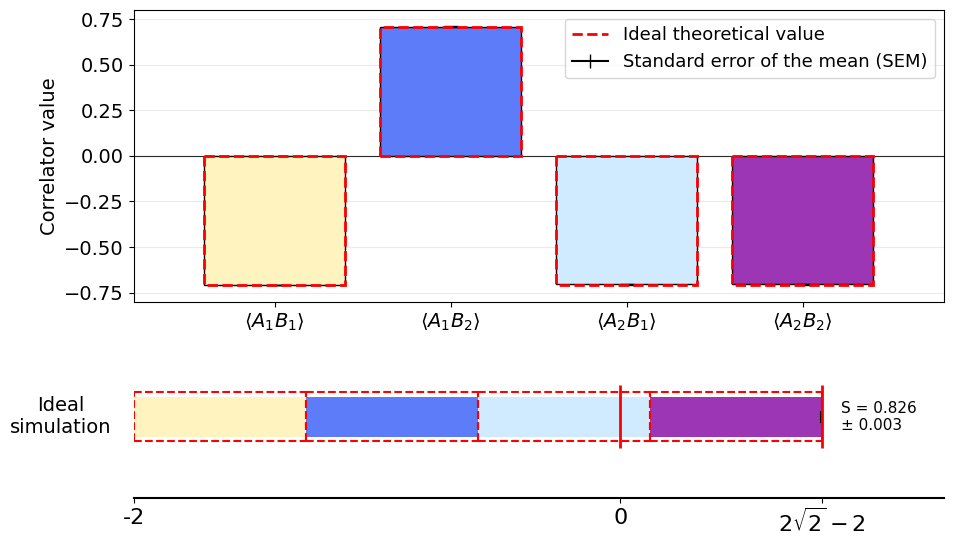

### Noiseless LF correlators: Always 3/4 Agent

`correlators_and_lf_values/noiseless/noiseless_always_3_4_agent_lf_correlator_comparison.png`

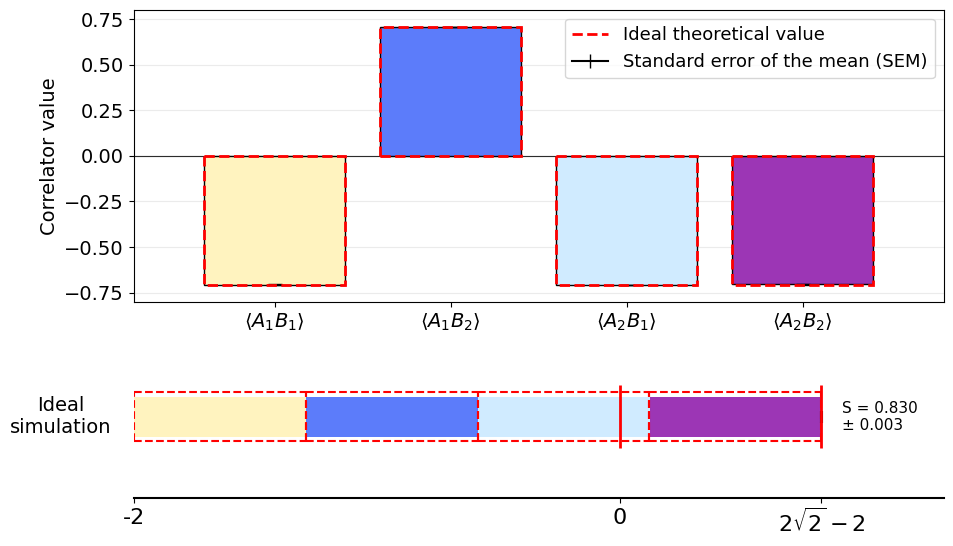

### Noise simulation and hardware LF correlators: Betting Agent

`correlators_and_lf_values/comparison/hardware_comparison_betting_agent_lf_correlator_comparison.png`

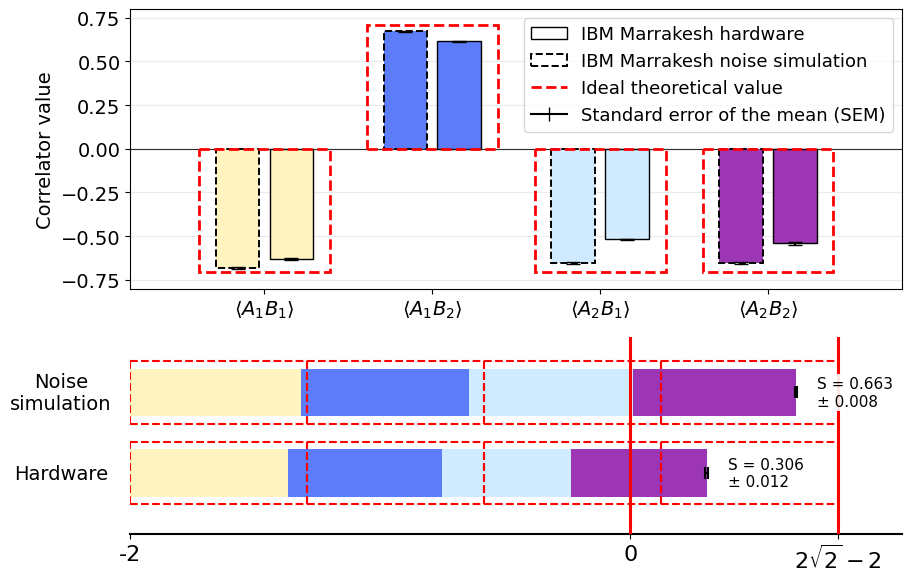

### Noise simulation and hardware LF correlators: Guessing Agent

`correlators_and_lf_values/comparison/hardware_comparison_guessing_agent_lf_correlator_comparison.png`

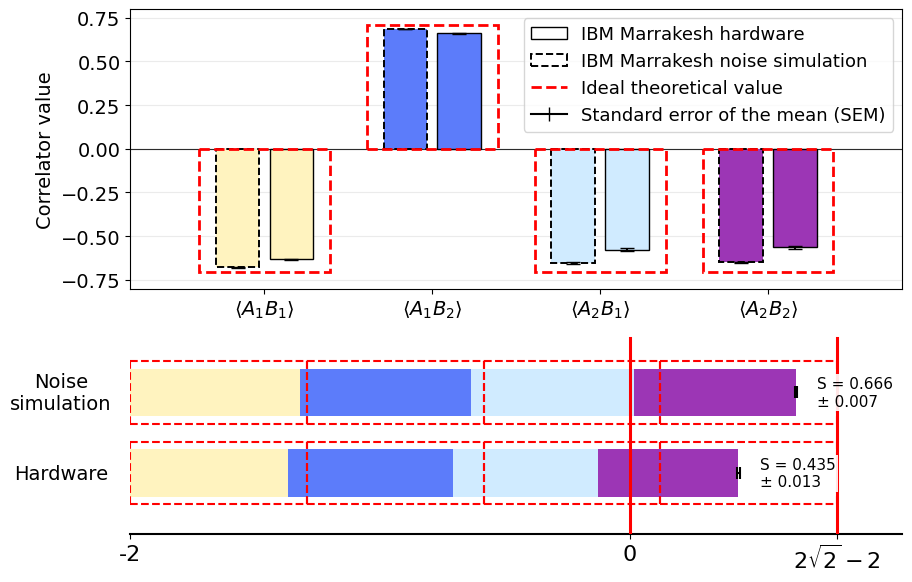

### Noise simulation and hardware LF correlators: Reflex Agent

`correlators_and_lf_values/comparison/hardware_comparison_reflex_agent_lf_correlator_comparison.png`

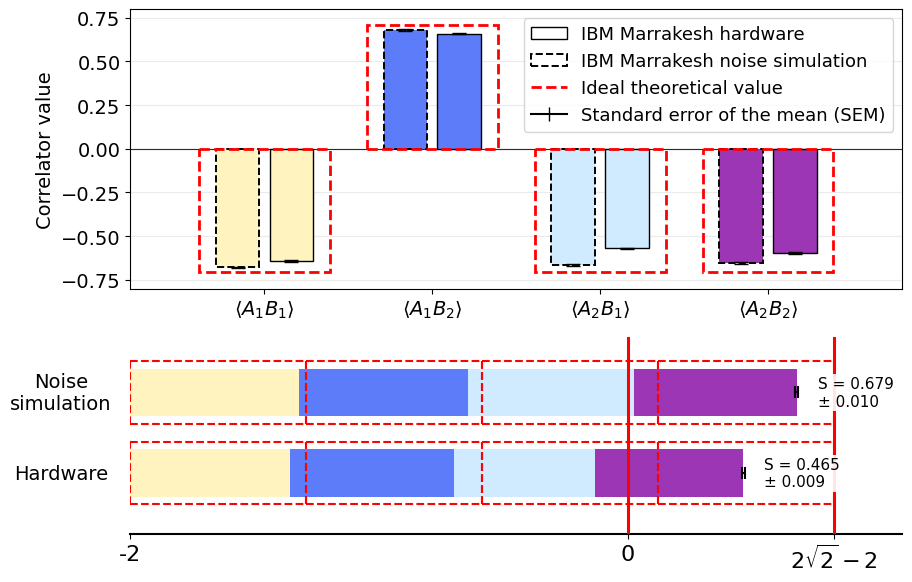

### Noise simulation and hardware LF correlators: Always 3/4 Agent

`correlators_and_lf_values/comparison/hardware_comparison_always_3_4_agent_lf_correlator_comparison.png`

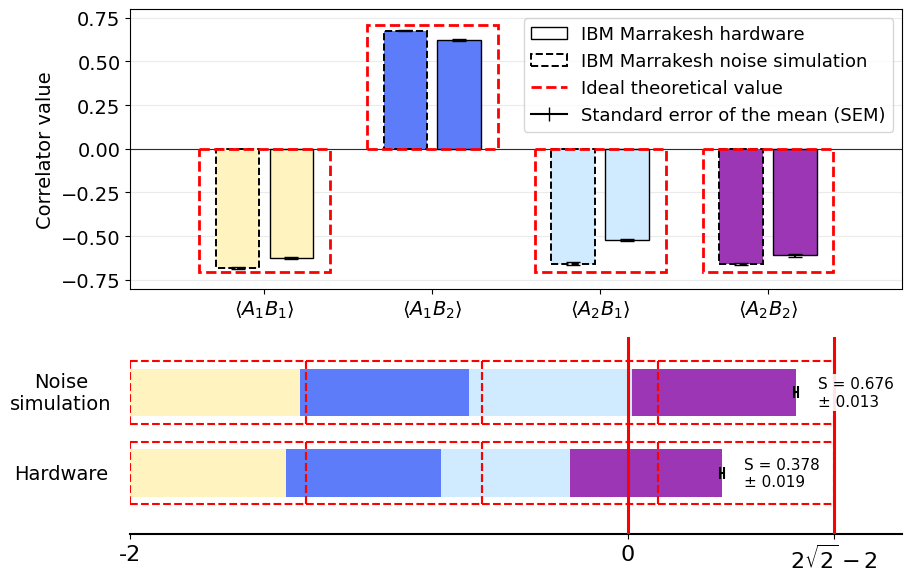

In [18]:
ae.plot_hardware_lf_agent_summary(
    results,
    OUTPUT_DIR / "correlators_and_lf_values" / "comparison",
    memory_inaccuracy_summary,
    show_epsilon_bounds=False,
)
plt.close("all")

ae.save_backend_lf_plot_group(
    results,
    OUTPUT_DIR / "correlators_and_lf_values" / "noiseless",
    "Noiseless",
    memory_inaccuracy_summary,
)
plt.close("all")

ae.plot_hardware_lf_comparison_per_agent(
    results,
    OUTPUT_DIR / "correlators_and_lf_values" / "comparison",
    memory_inaccuracy_summary,
)
plt.close("all")

## Agent Evaluation Plots

### Reflex Agent accuracy

`accuracy/reflex_agent_accuracy_comparison.png`

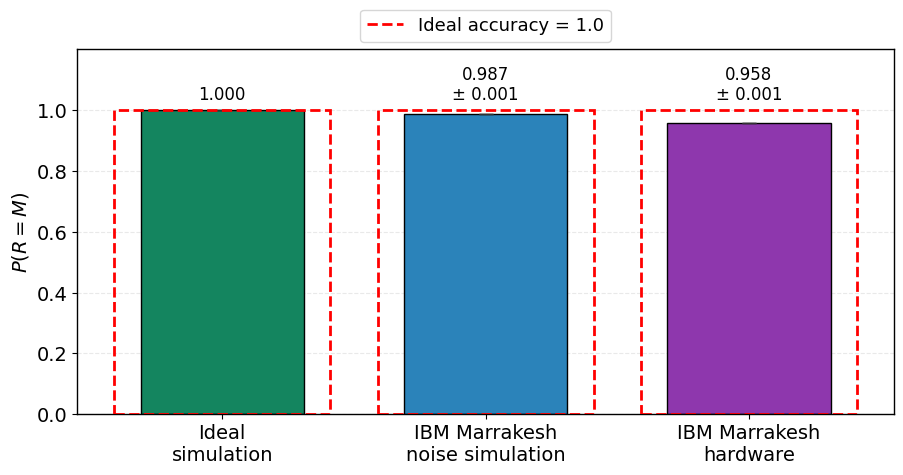

### Reflex Agent S_A/M agreement

`accuracy/reflex_agreement/reflex_agent_sa_m_agreement_accuracy.png`

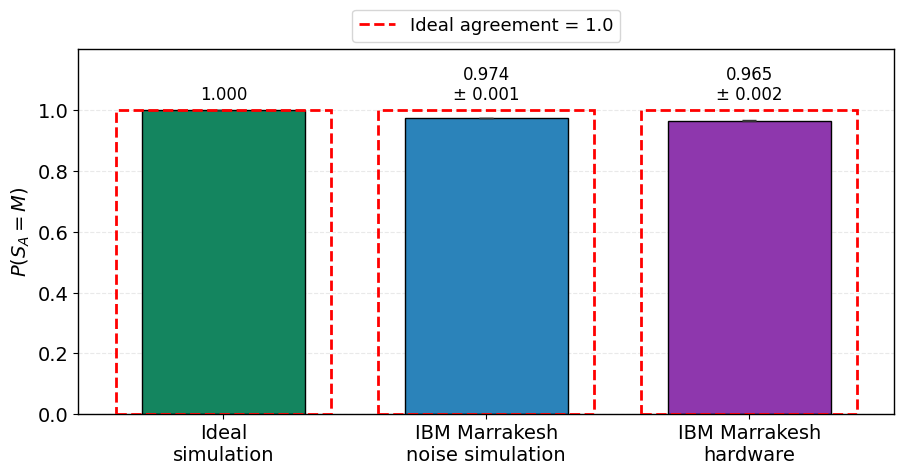

### Guessing Agent accuracy

`accuracy/guessing_agent_accuracy_comparison.png`

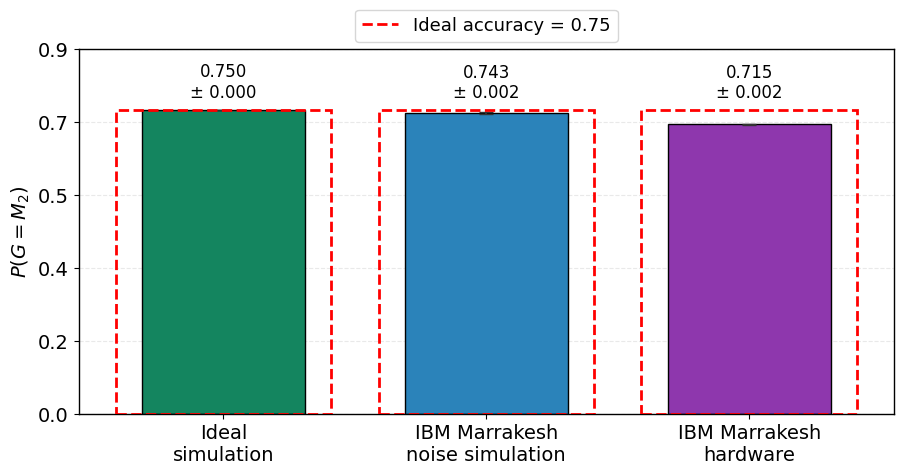

### Always 3/4 Agent accuracy

`accuracy/always_3_4_agent_accuracy_comparison.png`

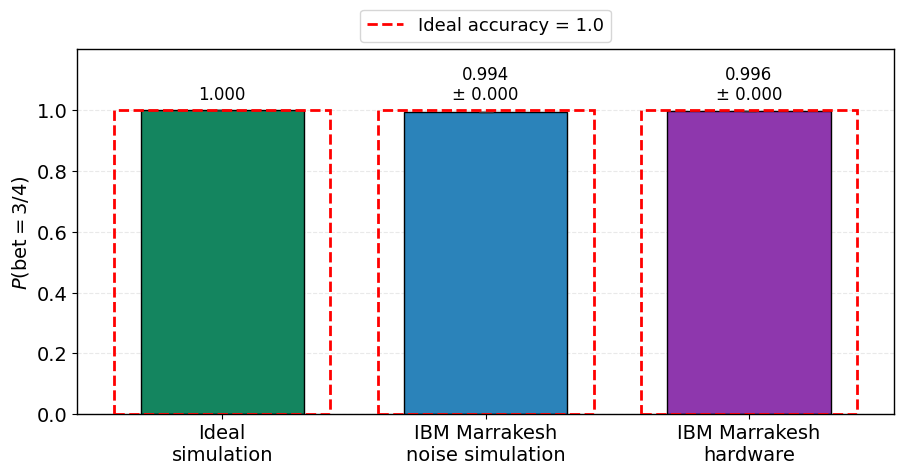

### Betting Agent accuracy

`accuracy/betting_agent_accuracy_comparison.png`

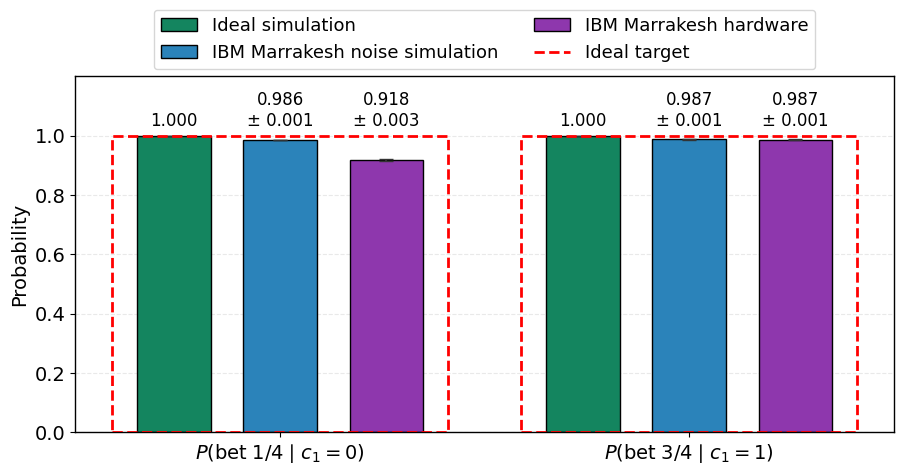

### Betting Agent vs Always 3/4 payoff

`comparison/betting_agent_vs_always_3_4_payoff_comparison.png`

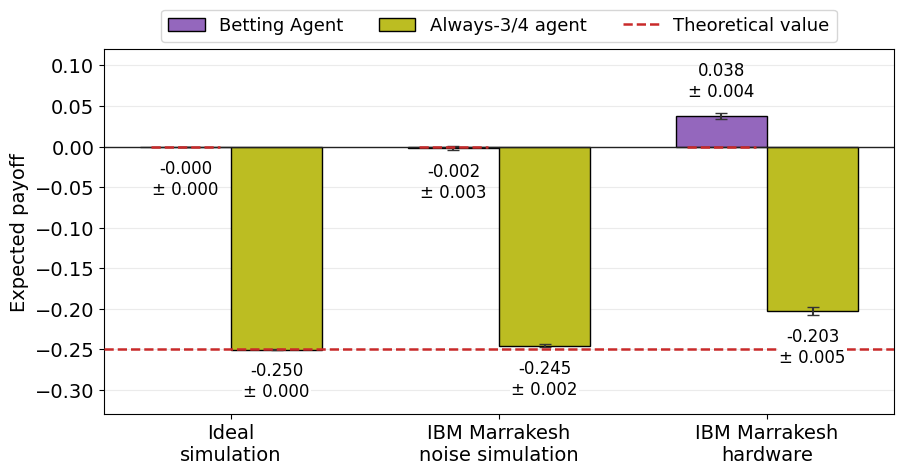

In [19]:
accuracy_dir = OUTPUT_DIR / "accuracy"

ae.save_accuracy_metric_plot(results, accuracy_dir, "reflex_accuracy")
plt.close("all")

ae.save_accuracy_metric_plot(results, accuracy_dir / "reflex_agreement", "reflex_sa_m_accuracy")
plt.close("all")

ae.save_accuracy_metric_plot(results, accuracy_dir, "guessing_accuracy")
plt.close("all")

ae.save_accuracy_metric_plot(results, accuracy_dir, "always_large_accuracy")
plt.close("all")

ae.plot_born_rule_accuracy(results, accuracy_dir)
plt.close("all")

ae.plot_always_large_vs_betting_payoff_comparison(results, OUTPUT_DIR / "comparison")
plt.close("all")

## Relaxed LF Robustness

### Tracking epsilon estimate

`memory_initialization/combined_memory_initialization_epsilon_comparison.png`

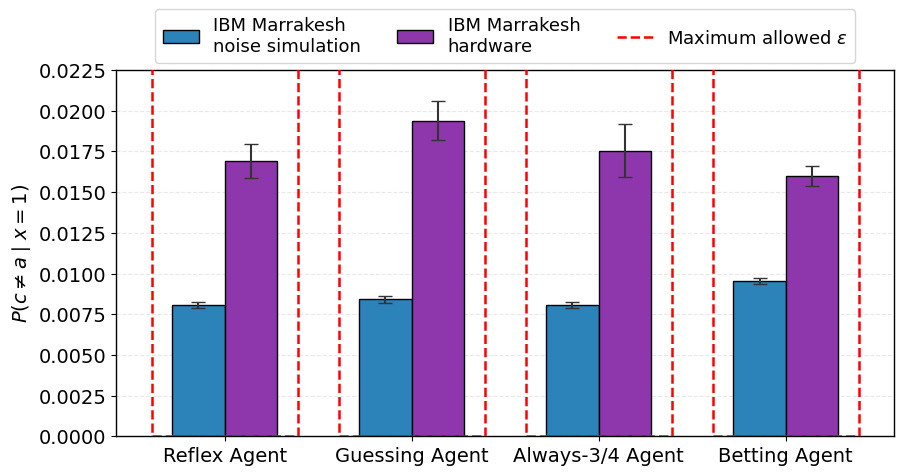

### Hardware LF violation summary with epsilon bounds

`correlators_and_lf_values/comparison/hardware_agent_lf_violation_summary_epsilon.png`

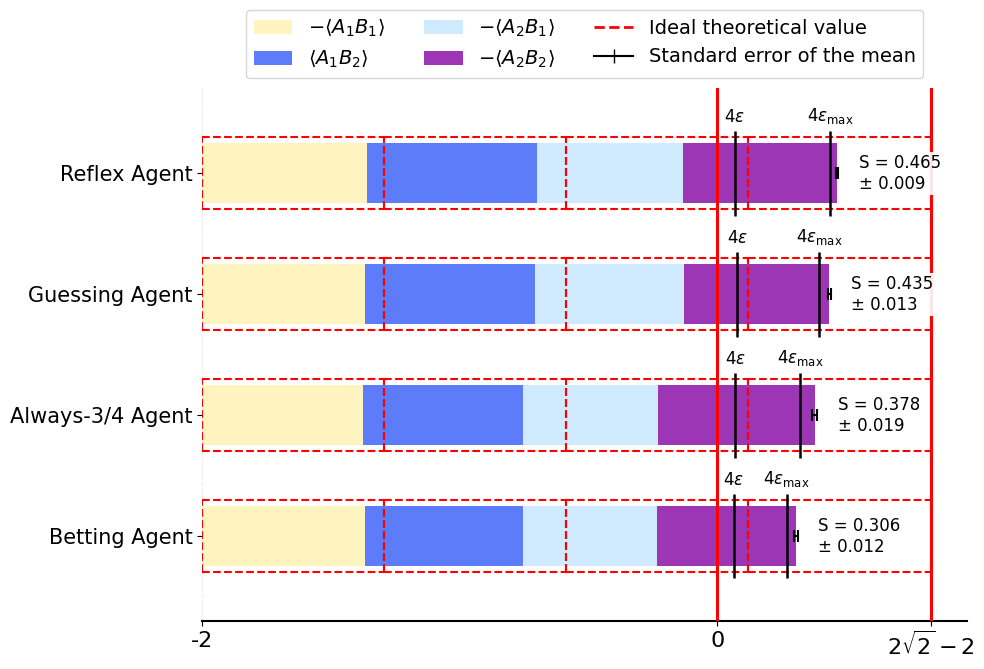

In [20]:
ae.plot_combined_memory_epsilon(
    memory_inaccuracy_summary,
    OUTPUT_DIR / "memory_initialization",
    tracking_epsilon_max_summary,
)
plt.close("all")

ae.plot_hardware_lf_agent_summary(
    results,
    OUTPUT_DIR / "correlators_and_lf_values" / "comparison",
    memory_inaccuracy_summary,
    show_epsilon_bounds=True,
)
plt.close("all")

## Displayed Plot Paths

In [21]:
pd.DataFrame({
    "plot_label": [str(path.relative_to(OUTPUT_DIR)) for path in displayed_plot_paths]
})

,plot_label
0,correlators_and_lf_values/comparison/hardware_...
1,correlators_and_lf_values/noiseless/noiseless_...
2,correlators_and_lf_values/noiseless/noiseless_...
3,correlators_and_lf_values/noiseless/noiseless_...
4,correlators_and_lf_values/noiseless/noiseless_...
5,correlators_and_lf_values/comparison/hardware_...
6,correlators_and_lf_values/comparison/hardware_...
7,correlators_and_lf_values/comparison/hardware_...
8,correlators_and_lf_values/comparison/hardware_...
9,accuracy/reflex_agent_accuracy_comparison.png
